<details>
<summary><b>Info</b></summary>

**Last Execution:** 2026-08-05

| Package | Version |
|---------|---------|
| **nnsight** | **0.8** |
| Python | 3.12.13 |
| torch | 2.13.0+cu126 |
| diffusers | 0.39.0 |

</details>

# Cross-Attention Ablation

## Introduction

🎨 In a text-to-image diffusion model, **cross-attention is the only place the prompt
touches the image**. Everything else — the convolutions, the self-attention, the scheduler —
operates on the image latent alone. So if you want to know how a prompt turns into a picture,
the cross-attention layers are where to look.

Stable Diffusion 1.4's UNet has 16 of them. That raises an obvious question with a
surprisingly direct answer: *what does each individual layer contribute?* We can find out by
removing one and regenerating. Same prompt, same seed, one layer silenced — anything that
changes is what that layer was doing.

The prompt is `"Starry Night"`, which is useful because it means two things at once: a literal
night sky full of stars, and a specific Van Gogh painting. Watching *which* of those survives
an ablation tells us where the model binds the painting.

📗 Based on the cross-attention ablation experiments in
[JadenFiotto-Kaufman/thesis](https://github.com/JadenFiotto-Kaufman/thesis), presented at the
CVPR 2026 HOW workshop ([companion repo](https://github.com/JadenFiotto-Kaufman/CVPR2026-HOW)).

## Setup

If using Colab, install NNsight and diffusers:
```
!pip install -U nnsight diffusers
```

In [1]:
try:
    import google.colab
    is_colab = True
except ImportError:
    is_colab = False

if is_colab:
    !pip install -U nnsight diffusers

In [2]:
import logging

import torch
import matplotlib.pyplot as plt
import nnsight
from nnsight import DiffusionModel

logging.getLogger("diffusers").setLevel(logging.ERROR)  # quiet the safety-checker notice

`DiffusionModel` wraps a HuggingFace `DiffusionPipeline` so every submodule — the UNet, its
attention blocks, the text encoder — is addressable inside a trace.

Note `torch_dtype`, not `dtype`: this keyword goes to `diffusers`, which still uses the older
spelling. Passing `dtype=` here is silently ignored and you end up in float32.

In [3]:
sd = DiffusionModel(
    "CompVis/stable-diffusion-v1-4",
    torch_dtype=torch.float16,
    safety_checker=None,
    dispatch=True,
    device_map="cuda",
)

# diffusers draws its own per-step progress bar, which would otherwise print 17 of them.
sd.pipeline.set_progress_bar_config(disable=True)

PROMPT = "Starry Night"
SEED = 43
STEPS = 50

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


## The baseline

With no interventions, calling `sd.generate(...)` is just the pipeline — no trace needed. We
only need the `with` form once we have something to do *during* the forward pass.

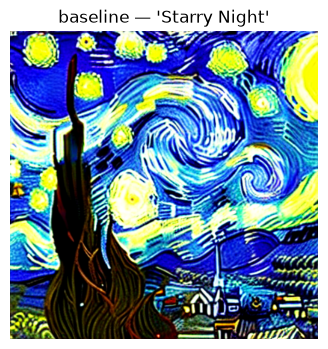

In [4]:
baseline = sd.generate(PROMPT, num_inference_steps=STEPS, seed=SEED).images[0]

plt.figure(figsize=(4, 4))
plt.imshow(baseline)
plt.title(f"baseline — {PROMPT!r}")
plt.axis("off")
plt.show()

Van Gogh, unmistakably. The model read `"Starry Night"` as the painting.

## Finding the cross-attention layers

In `diffusers`, a transformer block's `attn1` is self-attention and `attn2` is cross-attention.
`named_modules()` walks the envoy tree the same way it walks a `torch.nn.Module`, so we can
just filter by name. Sorting by path puts them in down → mid → up order, which is roughly the
order the forward pass visits them.

In [5]:
cross_attentions = sorted(
    ((name, envoy) for name, envoy in sd.unet.named_modules() if name.endswith(".attn2")),
    key=lambda pair: pair[0],
)
layers = [envoy for _, envoy in cross_attentions]

print(f"{len(layers)} cross-attention layers\n")
for index, (name, _) in enumerate(cross_attentions):
    print(f"  [{index:2d}] {name.removeprefix('model.unet.')}")

16 cross-attention layers

  [ 0] down_blocks.0.attentions.0.transformer_blocks.0.attn2
  [ 1] down_blocks.0.attentions.1.transformer_blocks.0.attn2
  [ 2] down_blocks.1.attentions.0.transformer_blocks.0.attn2
  [ 3] down_blocks.1.attentions.1.transformer_blocks.0.attn2
  [ 4] down_blocks.2.attentions.0.transformer_blocks.0.attn2
  [ 5] down_blocks.2.attentions.1.transformer_blocks.0.attn2
  [ 6] mid_block.attentions.0.transformer_blocks.0.attn2
  [ 7] up_blocks.1.attentions.0.transformer_blocks.0.attn2
  [ 8] up_blocks.1.attentions.1.transformer_blocks.0.attn2
  [ 9] up_blocks.1.attentions.2.transformer_blocks.0.attn2
  [10] up_blocks.2.attentions.0.transformer_blocks.0.attn2
  [11] up_blocks.2.attentions.1.transformer_blocks.0.attn2
  [12] up_blocks.2.attentions.2.transformer_blocks.0.attn2
  [13] up_blocks.3.attentions.0.transformer_blocks.0.attn2
  [14] up_blocks.3.attentions.1.transformer_blocks.0.attn2
  [15] up_blocks.3.attentions.2.transformer_blocks.0.attn2


## Ablating one layer

Three things have to line up, and each is a piece of the `nnsight` API worth knowing:

**Where to cut.** A cross-attention module ends with an output projection, `to_out[0]`. Its
`.input` is the post-attention, pre-projection activation — everything the layer computed,
just before it gets written back into the image stream. Zeroing there removes the layer's
contribution while letting attention itself run normally.

**How to cut.** `... .input[:] = 0` is an in-place write on the tensor the model is about to
use. Downstream sees zeros. (Assignment — `.input = x` — replaces it instead; either works
here, but in-place is the smaller edit.)

**When to cut.** Diffusion runs the UNet once *per denoising step*, so a one-shot intervention
would only affect the first of 50. `tracer.iter[:STEPS]` repeats the body every step.

That last one has a trap in it. **Bound the loop.** An unbounded `tracer.iter[:]` over-runs
the actual number of iterations, and everything after the loop — including `tracer.result.save()` —
is silently dropped, leaving you with a `NameError` and no obvious cause.

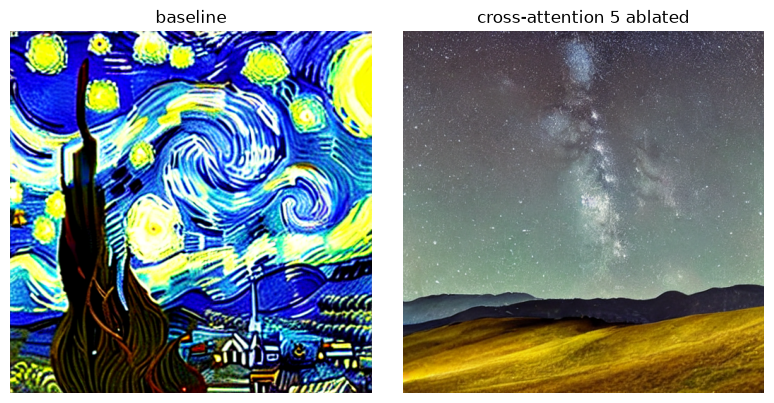

In [6]:
LAYER = 5

with sd.generate(PROMPT, num_inference_steps=STEPS, seed=SEED) as tracer:
    for _step in tracer.iter[:STEPS]:
        layers[LAYER].to_out[0].input[:] = 0
    ablated = tracer.result.save()

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, image, title in zip(axes, [baseline, ablated.images[0]],
                            ["baseline", f"cross-attention {LAYER} ablated"]):
    ax.imshow(image)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

The painting is gone and the photograph is left behind. Same prompt, same seed, same
everything except one silenced layer — and the output stops being a Van Gogh and becomes a
night sky over a hillside.

The literal content of `"Starry Night"` survived; the *reference* did not. Whatever binds those
two tokens to a specific painting rather than to stars-in-a-sky was routed through layer 5.

## Is layer 5 special?

One ablation is an anecdote. Repeating it for every layer — same prompt, same seed, one layer
ablated per generation — shows whether layer 5 is doing something distinctive or whether every
layer looks like this.

In [7]:
per_layer = []
for index in range(len(layers)):
    with sd.generate(PROMPT, num_inference_steps=STEPS, seed=SEED) as tracer:
        for _step in tracer.iter[:STEPS]:
            layers[index].to_out[0].input[:] = 0
        result = tracer.result.save()
    per_layer.append(result.images[0])

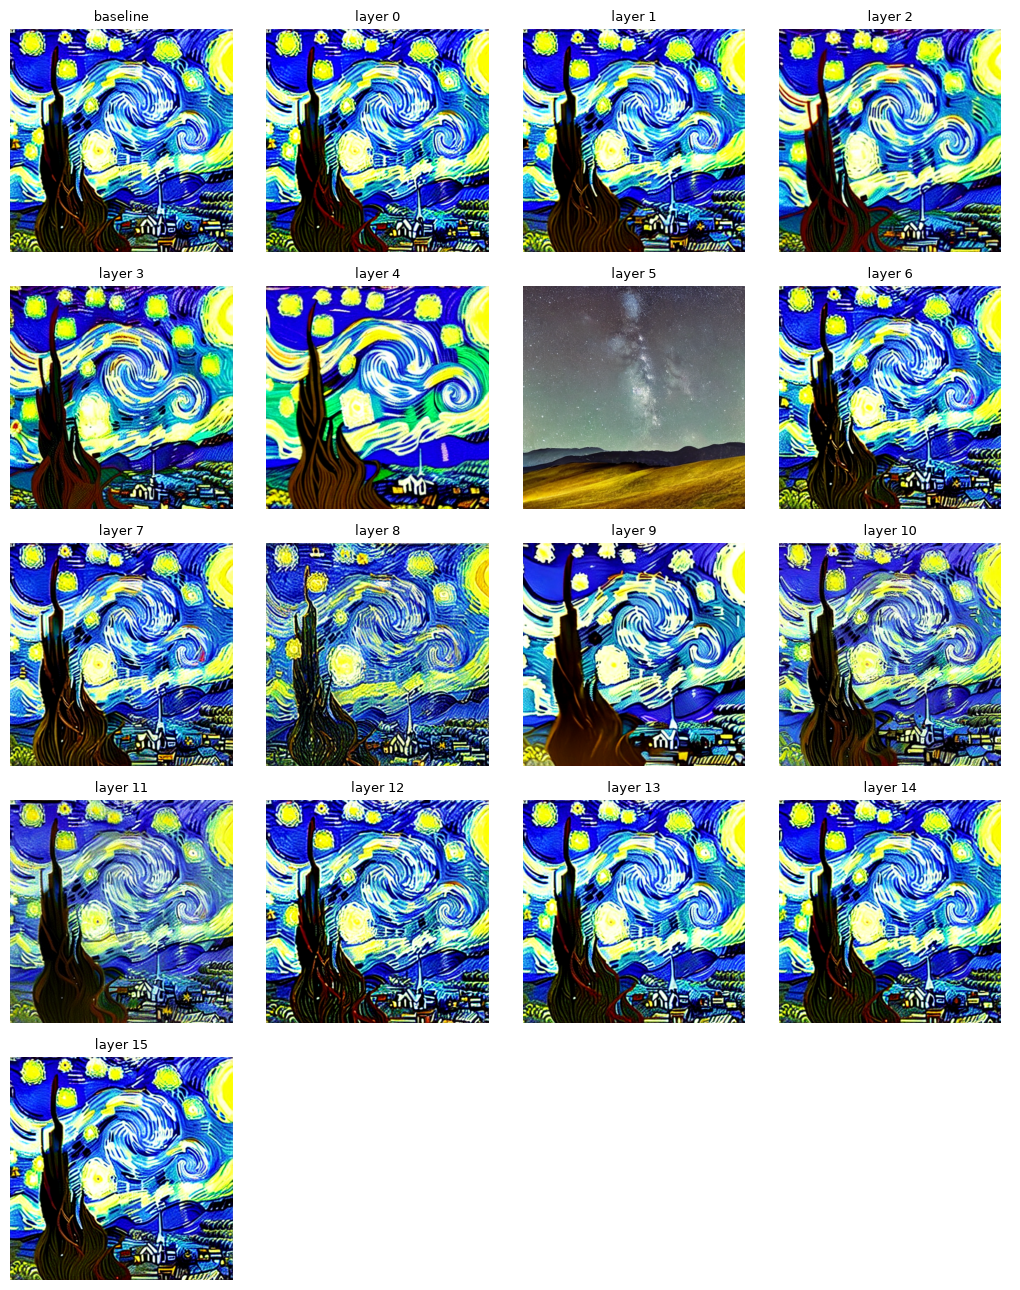

In [8]:
tiles = [("baseline", baseline)] + [(f"layer {i}", img) for i, img in enumerate(per_layer)]
n_cols = 4
n_rows = -(-len(tiles) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.6 * n_cols, 2.6 * n_rows))
for ax, (title, image) in zip(axes.flat, tiles):
    ax.imshow(image)
    ax.set_title(title, fontsize=9)
    ax.axis("off")
for ax in axes.flat[len(tiles):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

Fifteen of the sixteen tiles are a Van Gogh. Exactly one is a photograph.

The other layers are not doing *nothing* — layer 4 washes the palette out, 8 and 9 loosen the
brushwork, 11 softens the whole composition. But the subject survives all of them. Only
removing layer 5 changes what the image *is*, and it does so completely: no painterly texture
anywhere in the tile, just a photographic night sky over a hillside.

That is the shape of the finding. "Which layer matters?" has no clean answer — most of them
matter a little. "Which layer binds the prompt to a specific painting?" has a very clean one,
and it took sixteen generations and one line of intervention code to isolate it.

A caveat worth stating: this is one prompt and one seed. The claim that survives is about
*this* prompt's style binding, not a general theory of layer 5. Re-run with `"The Scream"` or
`"a photograph of a cat"` and see which layer, if any, plays the same role.

## Where to take this

The same three-line pattern generalises:

- **Ablate several at once** — `for index in sorted(LAYERS): layers[index]...`. Sort them:
  within a single forward pass, modules must be touched in forward order.
- **Ablate for part of the schedule** — `tracer.iter[:10]` silences a layer only for the first
  ten denoising steps. Early steps set composition, later steps set detail, and the difference
  is visible.
- **Scale instead of zero** — `.input[:] *= 0.5` for a partial ablation, or `*= 2` to amplify.
- **Ablate per token** — the attention is over the prompt's tokens, so you can zero the
  contribution of one word rather than the whole layer.

## Conclusion

🎉 Cross-attention ablation is about as small as an interpretability experiment gets — pick a
module, zero its output, regenerate — and on a model whose text conditioning is entirely
routed through 16 places, it is enough to localise where a prompt's *meaning* attaches.

Related: [Diffusion Lens](../probing/diffusion_lens.ipynb) for reading the text encoder's intermediate
states instead of ablating the UNet's, [Multiple Token Generation](../../../features/4_multiple_token.ipynb)
for `tracer.iter`, and [Setting Activations](../../../features/2_setting.ipynb) for the write API.

## References

- Fiotto-Kaufman, *Cross-attention ablation experiments on SD 1.4* — [github.com/JadenFiotto-Kaufman/thesis](https://github.com/JadenFiotto-Kaufman/thesis)
- CVPR 2026 HOW workshop companion code — [github.com/JadenFiotto-Kaufman/CVPR2026-HOW](https://github.com/JadenFiotto-Kaufman/CVPR2026-HOW)
- Rombach et al., [*High-Resolution Image Synthesis with Latent Diffusion Models*](https://arxiv.org/abs/2112.10752), CVPR 2022